## California Housing Price Prediction and Insights

### Objective
The goal of this project is to build a machine learning model that predicts the median house value of a California district using demographic, location, and housing data from the 1990 census.

Through this project, I aim to practice the complete machine learning workflow — including data cleaning, feature engineering, model building, and evaluation — while understanding the key factors that influence housing prices.

## Data Cleaning and Loading

In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost.callback import EarlyStopping
from xgboost import plot_importance


In [3]:
df = pd.read_csv('housing.csv')

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
df.dropna(inplace=True )

## EDA Insights

### 1 . median house price distribution

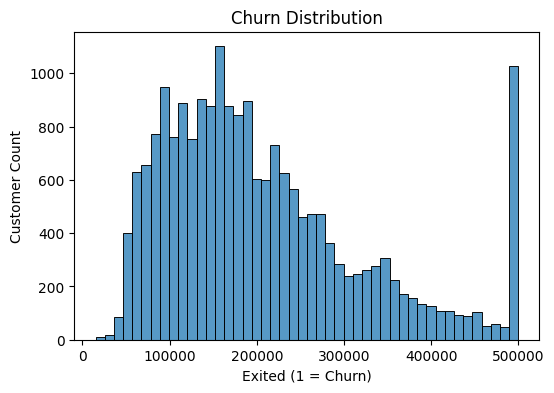

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(x='median_house_value', data=df)
plt.title("Churn Distribution")
plt.xlabel("Exited (1 = Churn)")
plt.ylabel("Customer Count")
plt.show()

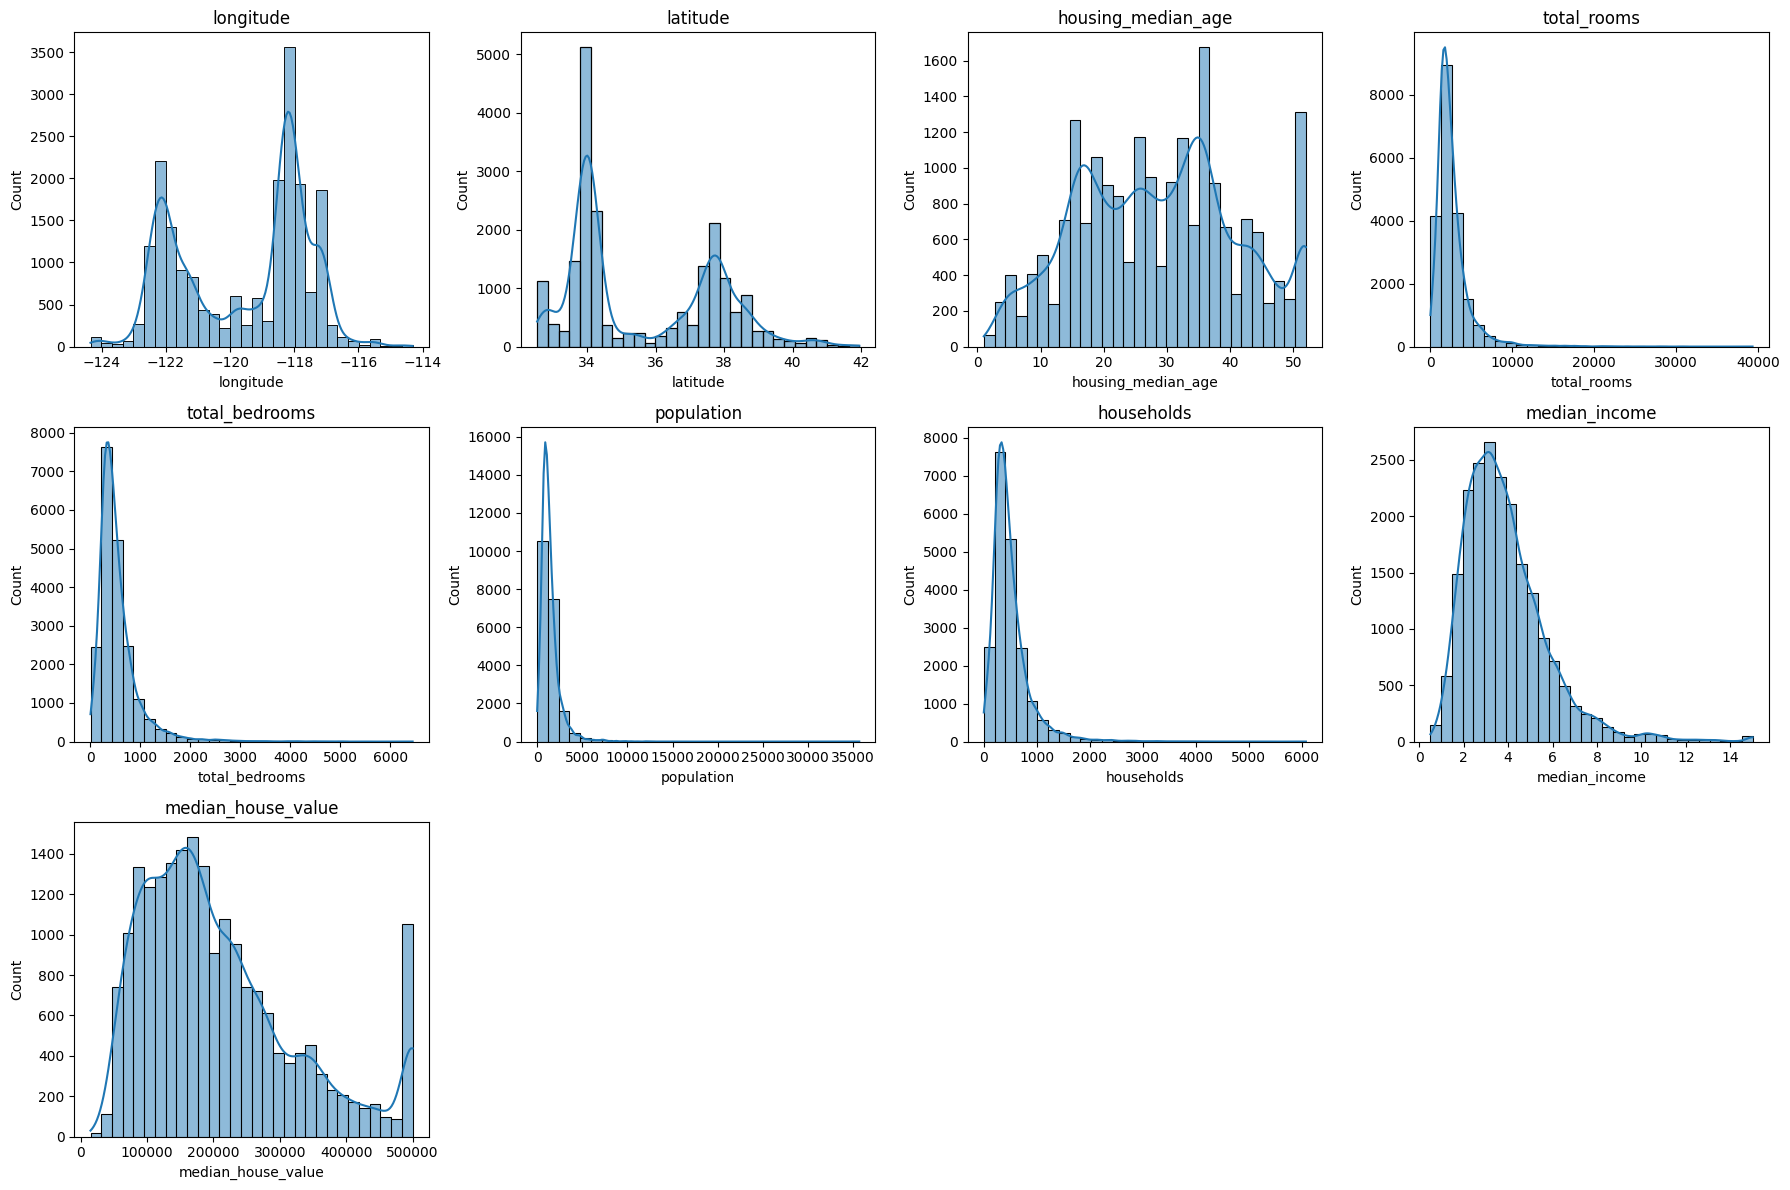

In [10]:
num_cols = df.select_dtypes(include=["float64"]).columns

# Set figure size
plt.figure(figsize=(18, 12))

# Loop through columns and create subplots
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 4, i)   # Adjust rows & columns if needed
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.tight_layout()

plt.show()

## Removing the Outliers

In [11]:
cols = ["total_rooms", 
        "total_bedrooms", 
        "population", 
        "households", 
        "median_income"]

# Create a copy to avoid modifying original
housing_clean = df.copy()

for col in cols:
    Q1 = housing_clean[col].quantile(0.25)
    Q3 = housing_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    housing_clean = housing_clean[
        (housing_clean[col] >= lower_bound) & 
        (housing_clean[col] <= upper_bound)
    ]

print("Original Shape:", df.shape)
print("After Outlier Removal:", housing_clean.shape)

Original Shape: (20433, 10)
After Outlier Removal: (17357, 10)


## Heatmap

<Figure size 1200x800 with 0 Axes>

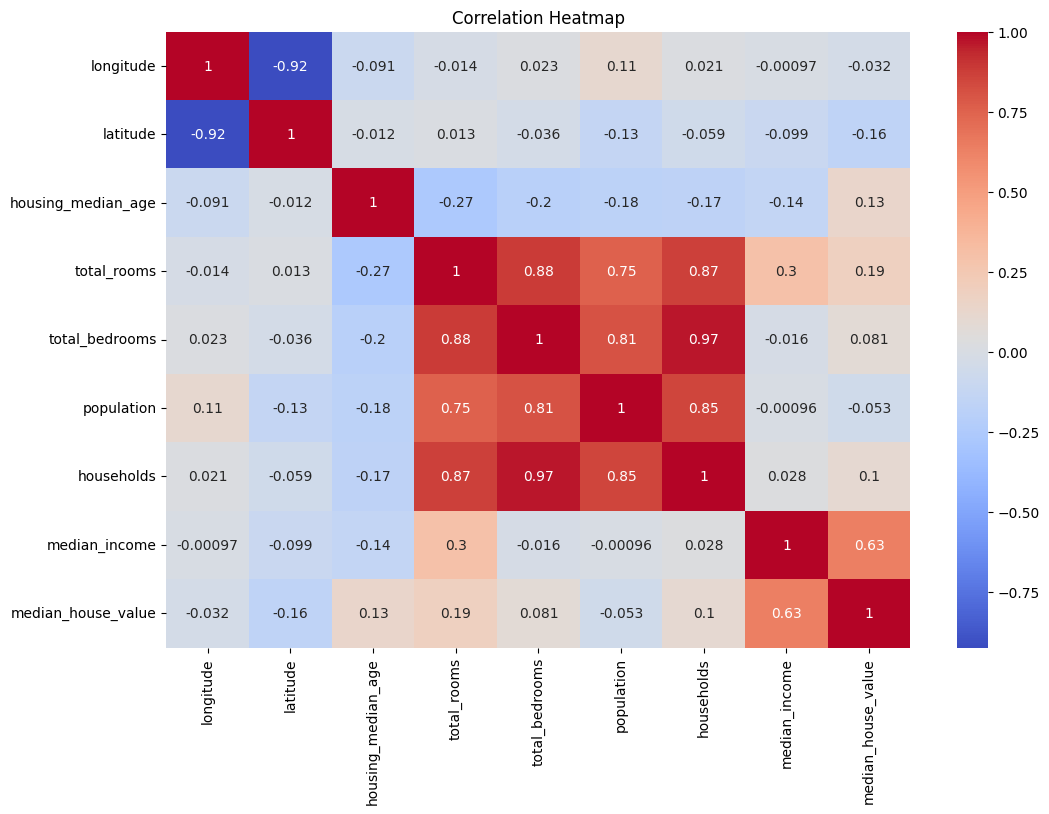

In [12]:
plt.figure(figsize=(12,8))
numeric_df = housing_clean.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis – Key Insight

The heatmap shows that median_income has the strongest positive correlation (0.63) with median_house_value, confirming that income level is a major driver of housing prices.

Size-related variables such as total_rooms, total_bedrooms, population, and households are highly correlated with each other, indicating multicollinearity. However, since the i will be using a XGBoost (a tree-based algorithm), I did not remove these features. Tree models are robust to multicollinearity and can automatically select the most informative splits.

Overall, the analysis suggests that economic and geographic factors influence house prices more strongly than raw structural counts alone, which aligns with real-world housing trends.

### Feature Engineering

In [13]:
housing_clean["rooms_per_household"] = housing_clean["total_rooms"] / housing_clean["households"]
housing_clean["bedrooms_per_room"] = housing_clean["total_bedrooms"] / housing_clean["total_rooms"]
housing_clean["population_per_household"] = housing_clean["population"] / housing_clean["households"]

In [14]:
target = "median_house_value"
features = housing_clean.drop(columns=[target])
X = features
y = housing_clean[target]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42
    )

## Pipeline

In [16]:
categoryical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["float64"]).columns.tolist()

prepocessor = ColumnTransformer(
    transformers=[
        ("num", 'passthrough', numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categoryical_cols)
    ]
)

pipe =Pipeline([
    ("preprocessor", prepocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",
        enable_categorical=True,
        device="cuda",
        n_estimators=800,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0
        ))
])

## hyperparameter tuning

In [17]:
param_grid = {
    "model__max_depth": [7, 8],
    "model__learning_rate": [0.02],
    "model__n_estimators": [1500],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]  ,
    'model__reg_lambda': [1.0, 10.0],
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring="neg_root_mean_squared_error"
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.02], 'model__max_depth': [7, 8], 'model__n_estimators': [1500], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [18]:
print(grid.best_params_)

{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.02, 'model__max_depth': 7, 'model__n_estimators': 1500, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}


In [19]:
best_params = grid.best_params_

In [20]:
xgb_best_params = {key.replace("model__", ""): value 
                   for key, value in best_params.items()}

In [21]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

In [30]:
# Fit preprocessor only on training data
prepocessor.fit(X_train_final)

# Transform train & validation
X_train_transformed = prepocessor.transform(X_train_final)
X_val_transformed = prepocessor.transform(X_val)

## Final Model Training

In [31]:
final_model = XGBRegressor(
    **xgb_best_params,
    objective="reg:squarederror",
    tree_method="hist",
    early_stopping_rounds=50,
    random_state=42
)

final_model.fit(
    X_train_transformed,
    y_train_final,
    eval_set=[(X_val_transformed, y_val)],
    verbose=True
)

[0]	validation_0-rmse:109316.23940
[1]	validation_0-rmse:108044.96017
[2]	validation_0-rmse:106846.05503
[3]	validation_0-rmse:105512.63551
[4]	validation_0-rmse:104172.90853
[5]	validation_0-rmse:103165.21009
[6]	validation_0-rmse:101882.00704
[7]	validation_0-rmse:100623.96889


[8]	validation_0-rmse:99456.73961
[9]	validation_0-rmse:98354.61753
[10]	validation_0-rmse:97190.38452
[11]	validation_0-rmse:96028.33762
[12]	validation_0-rmse:94916.10199
[13]	validation_0-rmse:93963.46043
[14]	validation_0-rmse:92884.93541
[15]	validation_0-rmse:91876.95269
[16]	validation_0-rmse:90892.80765
[17]	validation_0-rmse:89906.02488
[18]	validation_0-rmse:89033.40929
[19]	validation_0-rmse:88138.06886
[20]	validation_0-rmse:87234.28107
[21]	validation_0-rmse:86380.32582
[22]	validation_0-rmse:85485.97252
[23]	validation_0-rmse:84643.80599
[24]	validation_0-rmse:83805.79797
[25]	validation_0-rmse:82994.96490
[26]	validation_0-rmse:82288.10671
[27]	validation_0-rmse:81522.42803
[28]	validation_0-rmse:80754.48355
[29]	validation_0-rmse:80044.56456
[30]	validation_0-rmse:79305.43982
[31]	validation_0-rmse:78696.85264
[32]	validation_0-rmse:77994.81608
[33]	validation_0-rmse:77324.24981
[34]	validation_0-rmse:76663.73508
[35]	validation_0-rmse:76010.63732
[36]	validation_0-rmse

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [32]:
X_test_transformed = prepocessor.transform(X_test)

y_pred = final_model.predict(X_test_transformed)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Final RMSE:", rmse)

Final RMSE: 45793.202266709646


## Test Metrics

In [33]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Final RMSE:", rmse)
print("Final MAE:", mae)
print("Final R2:", r2)

Final RMSE: 45793.202266709646
Final MAE: 29410.295604118663
Final R2: 0.8167510620889342


## Top 5 Important Features

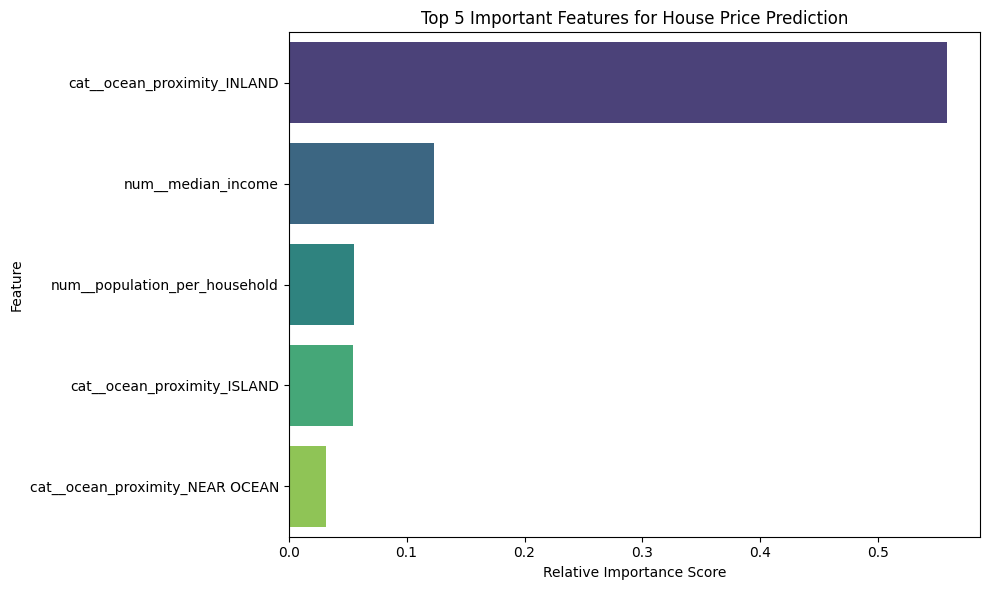

In [37]:
# 1. Get feature names from preprocessor
feature_names = prepocessor.get_feature_names_out()

# 2. Get importance scores
importances = final_model.feature_importances_

# 3. Create DataFrame
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# 4. Plot Top 10
plt.figure(figsize=(10,6))

sns.barplot(
    data=feat_df.head(5),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 5 Important Features for House Price Prediction")
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Final Insight

Feature importance analysis reveals that geographic factors, particularly whether a district is inland or near the ocean, are the strongest drivers of housing prices. Median income also plays a significant role, confirming that economic conditions strongly influence property valuation. Structural features such as room ratios contribute moderately, while house age has relatively lower impact.